In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


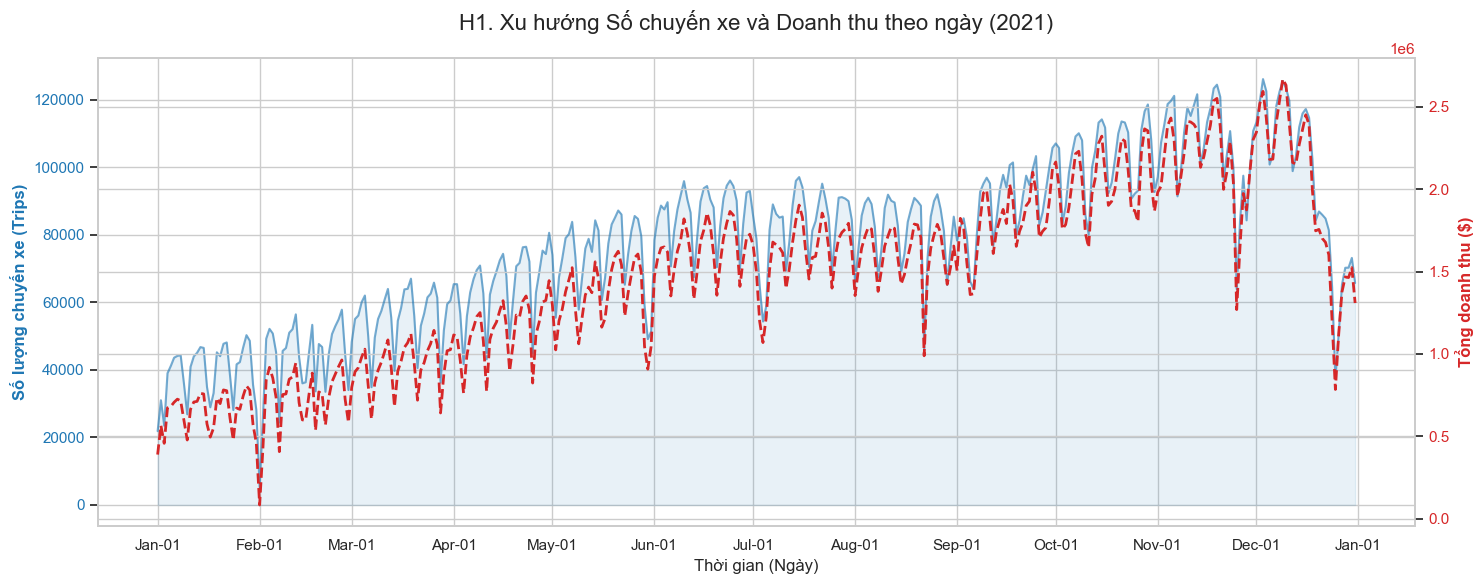

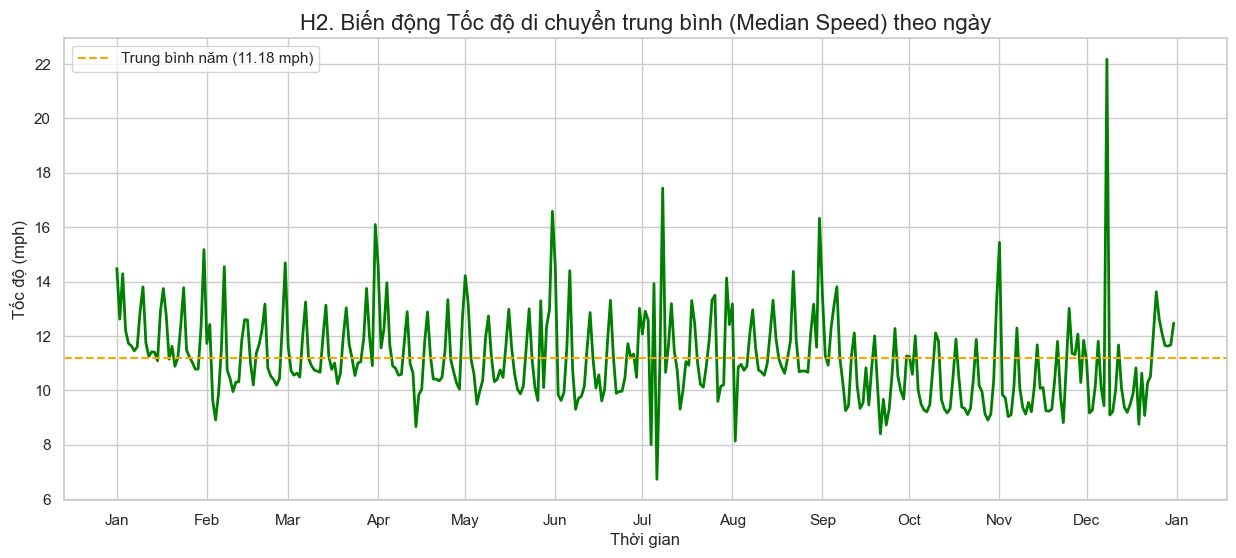

C:\Users\Admin\AppData\Local\Temp\ipykernel_9824\2392250581.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df_monthly, x=df_monthly['pickup_month'].dt.strftime('%B'), y='trips', palette='Blues_d')


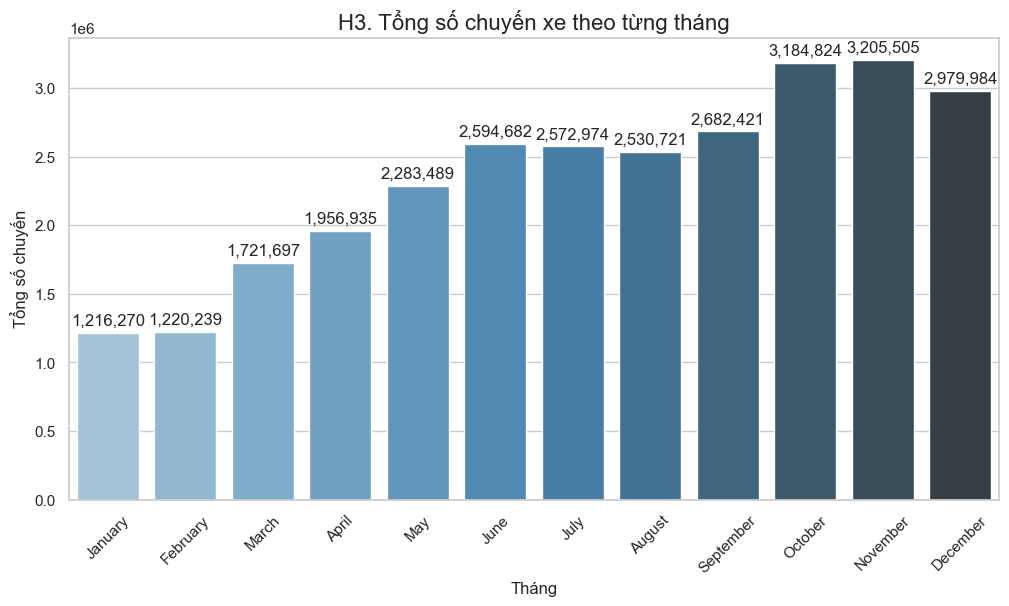

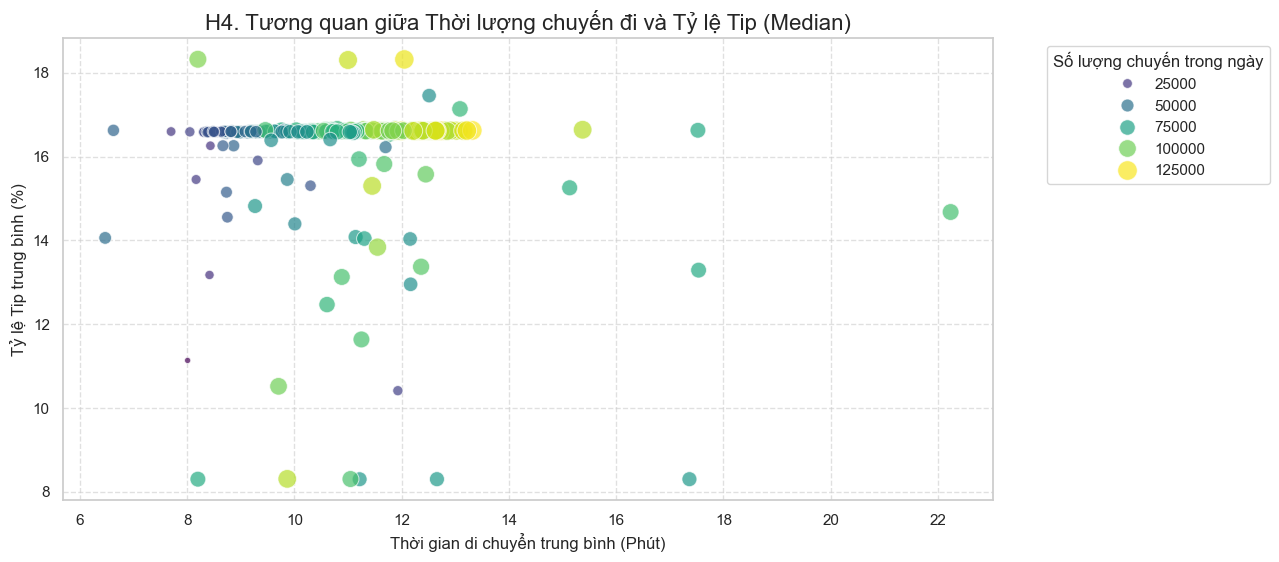

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import glob
import os

# Cấu hình giao diện đẹp
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# Đường dẫn file (Dùng file CSV bạn đã tạo ở bước trước)
output_dir = '../../processed/KPI_requirements'
daily_path = os.path.join(output_dir, 'kpi_daily_2021.csv')
monthly_path = os.path.join(output_dir, 'kpi_monthly_2021.csv')

# Load dữ liệu
df_daily = pd.read_csv(daily_path)
df_daily['pickup_date'] = pd.to_datetime(df_daily['pickup_date'])

df_monthly = pd.read_csv(monthly_path)
df_monthly['pickup_month'] = pd.to_datetime(df_monthly['pickup_month'])

# ==========================================
# HÌNH 1: Biểu đồ kết hợp (Dual Axis) - Số chuyến & Doanh thu theo ngày
# Thông điệp: Xem tương quan giữa lượng khách và doanh thu
# ==========================================
def plot_trips_revenue():
    fig, ax1 = plt.subplots(figsize=(15, 6))

    # Trục 1: Số chuyến (Cột hoặc Area)
    color = 'tab:blue'
    ax1.set_xlabel('Thời gian (Ngày)')
    ax1.set_ylabel('Số lượng chuyến xe (Trips)', color=color, fontweight='bold')
    ax1.plot(df_daily['pickup_date'], df_daily['trips'], color=color, alpha=0.6, label='Daily Trips')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.fill_between(df_daily['pickup_date'], df_daily['trips'], color=color, alpha=0.1)

    # Trục 2: Doanh thu (Đường)
    ax2 = ax1.twinx()  # Tạo trục y thứ 2
    color = 'tab:red'
    ax2.set_ylabel('Tổng doanh thu ($)', color=color, fontweight='bold')
    ax2.plot(df_daily['pickup_date'], df_daily['revenue_total'], color=color, linestyle='--', linewidth=2, label='Total Revenue')
    ax2.tick_params(axis='y', labelcolor=color)

    # Tiêu đề & Định dạng ngày
    plt.title('H1. Xu hướng Số chuyến xe và Doanh thu theo ngày (2021)', fontsize=16, pad=20)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    fig.tight_layout()
    plt.show()
plot_trips_revenue()


# ==========================================
# HÌNH 2: Biểu đồ đường - Tốc độ di chuyển trung bình (Speed P50)
# Thông điệp: Nhận diện các ngày tắc đường (tốc độ thấp) hoặc ngày lễ (tốc độ cao)
# ==========================================
def plot_speed_trend():
    plt.figure(figsize=(15, 6))

    # Vẽ đường tốc độ
    sns.lineplot(data=df_daily, x='pickup_date', y='speed_p50', color='green', linewidth=2)

    # Vẽ đường trung bình cả năm để so sánh
    avg_speed = df_daily['speed_p50'].mean()
    plt.axhline(avg_speed, color='orange', linestyle='--', label=f'Trung bình năm ({avg_speed:.2f} mph)')

    plt.title('H2. Biến động Tốc độ di chuyển trung bình (Median Speed) theo ngày', fontsize=16)
    plt.xlabel('Thời gian')
    plt.ylabel('Tốc độ (mph)')
    plt.legend()

    # Định dạng trục X
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

    plt.show()

plot_speed_trend()


# ==========================================
# HÌNH 3: Biểu đồ cột - Tổng số chuyến theo Tháng
# Thông điệp: Tháng nào cao điểm nhất trong năm?
# ==========================================
def plot_monthly_trips():
    plt.figure(figsize=(12, 6))

    # Vẽ cột
    barplot = sns.barplot(data=df_monthly, x=df_monthly['pickup_month'].dt.strftime('%B'), y='trips', palette='Blues_d')

    # Thêm nhãn số liệu lên đầu cột
    for p in barplot.patches:
        barplot.annotate(f'{int(p.get_height()):,}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center', va = 'center',
                         xytext = (0, 9),
                         textcoords = 'offset points')

    plt.title('H3. Tổng số chuyến xe theo từng tháng', fontsize=16)
    plt.xlabel('Tháng')
    plt.ylabel('Tổng số chuyến')
    plt.xticks(rotation=45)
    plt.show()

plot_monthly_trips()


# ==========================================
# HÌNH 4: Biểu đồ phân tán (Scatter) - Mối quan hệ Thời lượng & Tiền Tip
# Thông điệp: Chuyến đi dài hơn thì khách có Tip % cao hơn không?
# ==========================================
def plot_duration_vs_tip():
    plt.figure(figsize=(12, 6))

    # Lọc bỏ nhiễu (nếu có duration quá lớn)
    clean_df = df_daily[df_daily['duration_p50'] < 120]

    sns.scatterplot(data=clean_df, x='duration_p50', y='tip_percent_median',
                    size='trips', sizes=(20, 200), alpha=0.7, hue='trips', palette='viridis')

    plt.title('H4. Tương quan giữa Thời lượng chuyến đi và Tỷ lệ Tip (Median)', fontsize=16)
    plt.xlabel('Thời gian di chuyển trung bình (Phút)')
    plt.ylabel('Tỷ lệ Tip trung bình (%)')
    plt.legend(title='Số lượng chuyến trong ngày', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_duration_vs_tip()


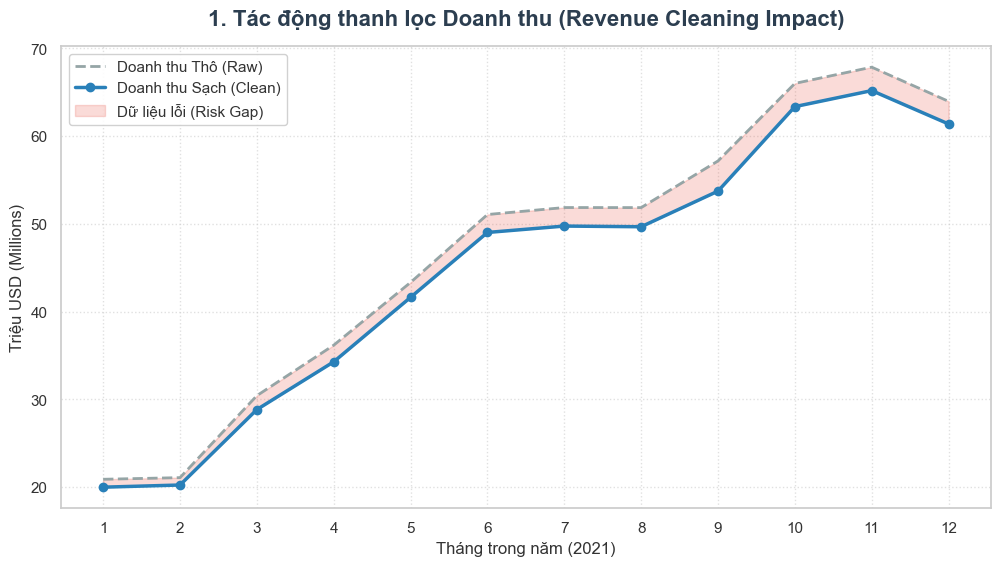

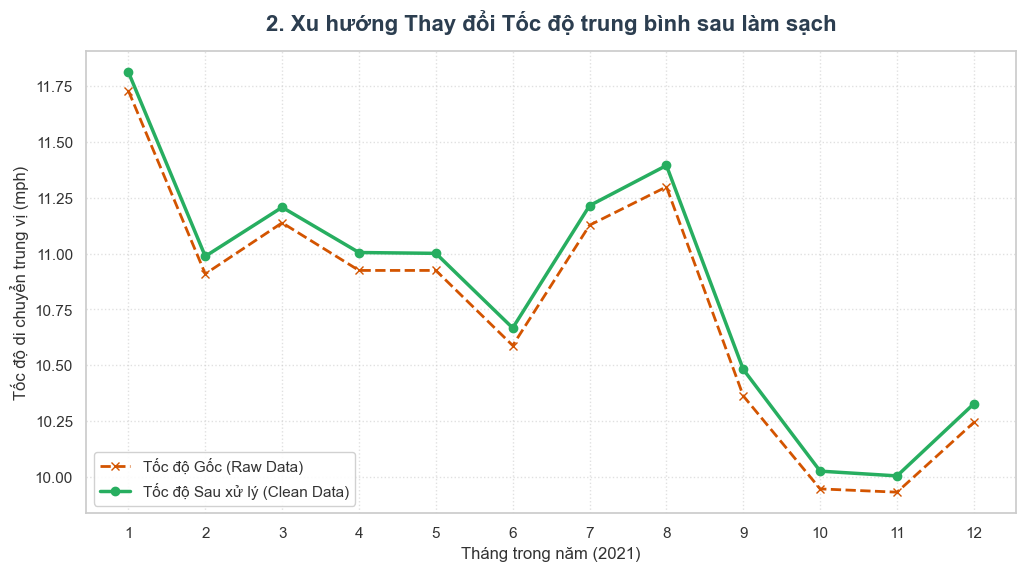

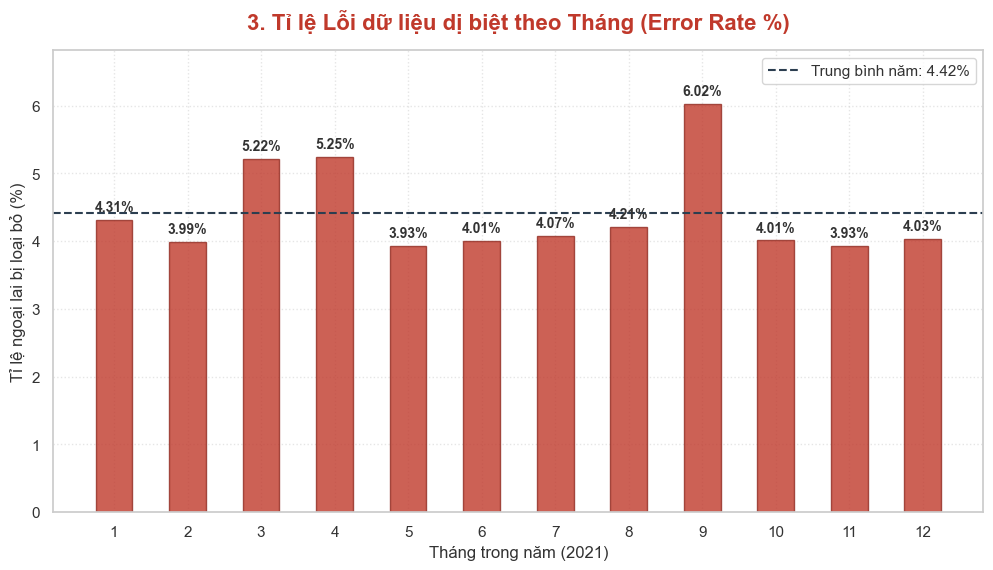

🎉 THÀNH CÔNG RỰC RỠ: 3 file ảnh đã được ném thẳng vào folder figures gốc:
 👉 d:\YELLOWTAXI-NYC2021\Data\Data\figures


In [2]:
import io
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# =========================================
# 1. CẤU HÌNH DỮ LIỆU GỐC
# =========================================
csv_data = """month,raw_revenue,clean_revenue,revenue_risk,raw_speed_p50,clean_speed_p50,speed_diff
1,20884410.36,19983585.78,900824.5799999982,11.729323308270676,11.81301736238445,-0.08369405411377429
2,21070991.96,20229642.8,841349.1600000001,10.90909090909091,10.987951807228916,-0.07886089813800545
3,30416152.080000002,28828786.14,1587365.9400000013,11.138121546961326,11.207547169811322,-0.06942562284999632
4,36170643.81,34273012.7,1897631.1099999994,10.924611055792191,11.004878048780487,-0.08026699298829598
5,43325013.019999996,41621030.0,1703983.0199999958,10.924643584521384,11.001140250855189,-0.07649666633380476
6,51060029.38,49014594.14,2045435.240000002,10.588235294117647,10.666666666666666,-0.07843137254901933
7,51854883.07,49742938.93,2111944.1400000006,11.127272727272725,11.214953271028039,-0.08768054375531342
8,51848407.3,49665334.78,2183072.519999996,11.299270072992702,11.394957983193276,-0.09568791020057432
9,57167326.81,53726985.720000006,3440341.089999996,10.36228287841191,10.481012658227849,-0.11872977981593813
10,66002830.19,63356421.43000001,2646408.7599999905,9.9456906729634,10.025316455696203,-0.07962578273280307
11,67852696.84,65183083.59,2669613.25,9.931034482758623,10.003913894324851,-0.07287941156622857
12,63956439.58,61377142.56,2579297.019999996,10.243298969072162,10.327077747989277,-0.0837787789171145"""

df = pd.read_csv(io.StringIO(csv_data))
df['raw_revenue_m'] = df['raw_revenue'] / 1_000_000
df['clean_revenue_m'] = df['clean_revenue'] / 1_000_000
df['error_rate_pct'] = (df['revenue_risk'] / df['raw_revenue']) * 100

# =========================================================
# 🛠️ TỰ ĐỘNG ĐỊNH VỊ ĐƯỜNG DẪN ĐÍCH VÀO FOLDER FIGURES GỐC
# =========================================================
current_dir = os.getcwd()
base_dir = current_dir

# Nếu file notebook đang chạy nằm trong src hoặc các folder con của src, lùi ra ngoài thư mục cha
for _ in range(3):
    if os.path.basename(base_dir) in ['ML', 'source_figures', 'src', 'calcular_KPI']:
        base_dir = os.path.dirname(base_dir)

# Đích đến chính xác: Thư mục Data/figures/ gốc
SAVE_DIR = os.path.join(base_dir, "Data", "figures")
os.makedirs(SAVE_DIR, exist_ok=True)

# CẤU HÌNH STYLE NỀN TRẮNG CHUẨN KHOA HỌC
sns.set_theme(style="whitegrid") 
plt.rcParams.update({
    'font.size': 12,
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.unicode_minus': False
})

# =========================================
# ẢNH 1: REVENUE IMPACT (Màu Xanh Navy & Đỏ Đô)
# =========================================
plt.figure(figsize=(12, 6))
plt.plot(df['month'], df['raw_revenue_m'], color='#95a5a6', linestyle='--', linewidth=2, label='Doanh thu Thô (Raw)')
plt.plot(df['month'], df['clean_revenue_m'], color='#2980b9', marker='o', linewidth=2.5, label='Doanh thu Sạch (Clean)')
plt.fill_between(df['month'], df['clean_revenue_m'], df['raw_revenue_m'], color='#e74c3c', alpha=0.2, label='Dữ liệu lỗi (Risk Gap)')

plt.title('1. Tác động thanh lọc Doanh thu (Revenue Cleaning Impact)', fontsize=16, color='#2c3e50', pad=15)
plt.ylabel('Triệu USD (Millions)', fontsize=12)
plt.xlabel('Tháng trong năm (2021)', fontsize=12)
plt.xticks(df['month'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

save_path_1 = os.path.join(SAVE_DIR, '1_revenue_impact.png')
plt.savefig(save_path_1, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# =========================================
# ẢNH 2: SPEED TREND (Đã sửa đơn vị sang mph)
# =========================================
plt.figure(figsize=(12, 6))
plt.plot(df['month'], df['raw_speed_p50'], color='#d35400', linestyle='--', marker='x', linewidth=2, label='Tốc độ Gốc (Raw Data)')
plt.plot(df['month'], df['clean_speed_p50'], color='#27ae60', marker='o', linewidth=2.5, label='Tốc độ Sau xử lý (Clean Data)')

plt.title('2. Xu hướng Thay đổi Tốc độ trung bình sau làm sạch', fontsize=16, color='#2c3e50', pad=15)
plt.ylabel('Tốc độ di chuyển trung vị (mph)', fontsize=12) 
plt.xlabel('Tháng trong năm (2021)', fontsize=12)
plt.xticks(df['month'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)

save_path_2 = os.path.join(SAVE_DIR, '2_speed_trend.png')
plt.savefig(save_path_2, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# =========================================
# ẢNH 3: ERROR RATE (%) (Đã sửa lỗi tràn nhãn dán chữ)
# =========================================
plt.figure(figsize=(12, 6))
bars = plt.bar(df['month'], df['error_rate_pct'], color='#c0392b', alpha=0.8, edgecolor='#922b21', width=0.5)
avg_error = df['error_rate_pct'].mean()
plt.axhline(avg_error, color='#2c3e50', linestyle='--', linewidth=1.5, label=f'Trung bình năm: {avg_error:.2f}%')      

plt.title('3. Tỉ lệ Lỗi dữ liệu dị biệt theo Tháng (Error Rate %)', fontsize=16, color='#c0392b', pad=15)
plt.ylabel('Tỉ lệ ngoại lai bị loại bỏ (%)', fontsize=12)
plt.xlabel('Tháng trong năm (2021)', fontsize=12)
plt.xticks(df['month'])
plt.ylim(0, max(df['error_rate_pct']) + 0.8) 
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', frameon=True, facecolor='white')

# Sử dụng cơ chế offset điểm thông minh chống đè chữ
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 4),  
                 textcoords="offset points",
                 ha='center', va='bottom', color='#333333', fontsize=10, fontweight='bold')

save_path_3 = os.path.join(SAVE_DIR, '3_error_rate.png')
plt.savefig(save_path_3, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"🎉 THÀNH CÔNG RỰC RỠ: 3 file ảnh đã được ném thẳng vào folder figures gốc:\n 👉 {os.path.abspath(SAVE_DIR)}")